# 📈 Tema 25: Regresión Logística y Modelado de Probabilidades

¡Bienvenido/a al estudio de la Regresión Logística!

A pesar de llevar la palabra "Regresión" en su nombre, este es uno de los algoritmos de **Clasificación** más utilizados en la industria (desde aprobaciones de créditos bancarios hasta diagnósticos médicos). A lo largo de este cuaderno, aprenderemos cómo transformar una combinación lineal de variables en una probabilidad acotada estrictamente entre $0$ y $1$, y cómo optimizar sus coeficientes utilizando diferentes solucionadores estadísticos.

## 🚀 Contenido del Cuaderno

1. **Fundamentos Conceptuales:** La Función Sigmoide y la Máxima Verosimilitud.
2. **Visualización Matemática:** Graficando el comportamiento de la Sigmoide.
3. **Métricas de Diagnóstico Avanzado:** La Curva ROC y el Área Bajo la Curva (AUC).
4. **Proyecto Práctico:** Clasificación de Medicamentos por Origen de Proveedor (`drugs.csv`).
5. **Evaluación de Solucionadores:** Comparativa entre `lbfgs`, `newton-cg`, `sag` y `saga`.
6. **Nivel Pro:** Diseñando un Pipeline de Clasificación Automatizado con OOP.
7. **Glosario Técnico y Conclusión.**

---
> **Instrucciones:** Ejecuta las celdas de forma secuencial. Asegúrate de tener el archivo `drugs.csv` en tu directorio de trabajo.

## 1. Descubre la Regresión Logística: Función Sigmoide y Máxima Verosimilitud

Una regresión lineal simple intenta predecir una línea recta que va desde el infinito negativo al infinito positivo. Esto no nos sirve para clasificar (no existen probabilidades menores a $0$ ni mayores a $1$).

Para solucionar esto, la Regresión Logística toma la ecuación lineal clásica:
$$z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n$$

Y la introduce dentro de la **Función Sigmoide** (también conocida como función logística):
$$S(z) = \frac{1}{1 + e^{-z}}$$

La función sigmoide actúa como un "embudo" o transformador: sin importar si el valor de $z$ es un número inmenso o extremadamente negativo, la salida siempre estará contenida de forma suave en el rango de $[0, 1]$, representando la **probabilidad de pertenecer a la clase positiva**.

### ¿Cómo aprende el algoritmo? (Máxima Verosimilitud)
En lugar de usar Mínimos Cuadrados (como en regresión lineal), los coeficientes $\beta$ se estiman mediante **Máxima Verosimilitud (Maximum Likelihood Estimation)**. Este método busca los parámetros que maximicen la probabilidad de que el modelo reproduzca correctamente las etiquetas reales observadas en el dataset, apoyándose en algoritmos de optimización numérica como el *Descenso de Gradientes* o el método de *Newton-Raphson*.

✅ Gráfica conceptual generada con éxito como 'demostracion_sigmoide.png'.


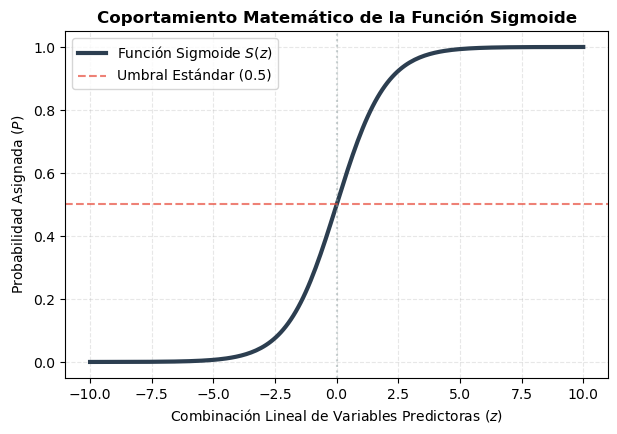

In [4]:
# --- DEMOSTRACIÓN CONCEPTUAL: LA CURVA SIGMOIDE ---
import numpy as np 
import matplotlib.pyplot as plt 

# Definimos la función matemática de la Sigmoide
def calcular_sigmoide(z):
        return 1/(1 + np.exp(-z))

# Generamos un rango de valores de combinación lineal desde -10 hasta 10
valores_z = np.linspace(-10, 10, 200)
probabilidades = calcular_sigmoide(valores_z)

# Creamos la gráfica descriptiva 
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(valores_z, probabilidades, color='#2c3e50', linewidth=3, label='Función Sigmoide $S(z)$')

# Añadimos líneas guía para comprender el umbral de clasificación estándar (0,5)
ax.axhline(0.5, color='#e74c3c', linestyle='--', alpha=0.7, label='Umbral Estándar (0.5)')
ax.axvline(0.0, color='#95a5a6', linestyle=':', alpha=0.5)

ax.set_title('Coportamiento Matemático de la Función Sigmoide', fontsize=12, fontweight='bold')
ax.set_xlabel('Combinación Lineal de Variables Predictoras ($z$)')
ax.set_ylabel('Probabilidad Asignada ($P$)')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)

# guardamos el gráfico siguiendo las buenas prácticas de visualizacion estructurada
plt.savefig('demostracion_sigmoide.png', dpi=300, bbox_inches='tight')
print("✅ Gráfica conceptual generada con éxito como 'demostracion_sigmoide.png'.")

## 2. Evaluación del Modelo con Curva ROC y AUC

Cuando el modelo nos devuelve una probabilidad (ej. $0.65$), necesitamos un **Umbral de Clasificación** para tomar una decisión final. Por defecto, si la probabilidad es $\ge 0.5$, se clasifica como clase positiva ($1$); si es menor, como clase negativa ($0$).

Sin embargo, en medicina o finanzas, mover el umbral puede salvar vidas o millones de dólares. Para evaluar el rendimiento del modelo sin depender de un único umbral estático, utilizamos la **Curva ROC (Receiver Operating Characteristic)**.

* **Eje Y (Tasa de Verdaderos Positivos / Sensibilidad):** Qué porcentaje de los casos positivos reales logramos atrapar correctamente.
* **Eje X (Tasa de Falsos Positivos / 1 - Especificidad):** Qué porcentaje de falsas alarmas lanzamos sobre casos que eran realmente negativos.

El **AUC (Área bajo la curva)** resume esta gráfica en un solo número de $0.5$ a $1.0$. Un AUC de $1.0$ representa la perfección predictiva absoluta.

---
## 📝 Proyecto Práctico: Clasificación por Origen de Proveedor

**Problema Farmacéutico:** Disponemos de la base de datos histórica de pacientes `drugs.csv`. El departamento de compras e investigación médica requiere modelar si el medicamento adecuado para un futuro paciente será de **Origen Nacional** o de **Origen Extranjero**.

De acuerdo con la ficha del problema, los fármacos se distribuyen de la siguiente manera:
* **Proveedor Nacional (Clase Positiva = 1):** Fármaco A, Fármaco B y Fármaco C.
* **Proveedor Extranjero (Clase Negativa = 0):** Fármaco X y Fármaco Y.

**Objetivos del paso a paso:**
1. Cargar el dataset y codificar características categóricas independientes usando `LabelEncoder()`.
2. Mapear y transformar la variable objetivo `Drug` en la regla binaria de proveedores (Nacional/Extranjero).
3. Entrenar la Regresión Logística evaluando 4 solucionadores de optimización: `lbfgs`, `newton-cg`, `sag` y `saga`.
4. Analizar la eficacia del algoritmo óptimo mediante su reporte de clasificación y gráfico ROC.

In [8]:
# --- PASO 1: CARGA, TRANSFORMACIÓN Y ESCALADO ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Cargamos el archivo de datos
df_original = pd.read_csv('drugs.csv')

X_features = df_original.drop('Drug', axis=1)
y_raw = df_original['Drug']

# 2. Codificación de variables independientes con LabelEncoder
le_encoder = LabelEncoder()
for columna in ['Sex', 'BP', 'Cholesterol']:
    X_features[columna] = le_encoder.fit_transform(X_features[columna])

# 3. Transformación de la Variable Objetivo según Proveedor
# Nacional (A, B, C) -> 1 | Extranjero (X, Y) -> 0
def transformar_a_proveedor(nombre_droga):
    if nombre_droga in ['drugA', 'drugB', 'drugC']:
        return 1 # Nacional
    else:
        return 0 # Extranjero

y_binario = y_raw.apply(transformar_a_proveedor)

print("=== Distribución del Target de Negocio ===")
conteo = y_binario.value_counts()
print(f"Medicamentos de Proveedor Extranjero (0): {conteo[0]} ({conteo[0]/len(y_binario)*100:.1f}%)")
print(f"Medicamentos de Proveedor Nacional (1): {conteo[1]} casos ({conteo[1]/len(y_binario)*100:.1f}%)")

# 4. Separación en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_binario, test_size=0.2,
                                                   random_state=42, stratify=y_binario)

# 5. Estandarización de Características
# ¡CRÍTICO!: Los optimizadores numéricos de Regresión Logística (especialmente SAG/SAGA)
# requieren estandarización para asegurar la convergencia de la Maxima Verosimilitud.
scaler_features = StandardScaler()
X_train_scaled = scaler_features.fit_transform(X_train)
X_test_scaled = scaler_features.transform(X_test)

print("\n✅ Preprocesamiento completado. Características escaladas listas para la optimización.")

=== Distribución del Target de Negocio ===
Medicamentos de Proveedor Extranjero (0): 145 (72.5%)
Medicamentos de Proveedor Nacional (1): 55 casos (27.5%)

✅ Preprocesamiento completado. Características escaladas listas para la optimización.


### Paso 2: Evaluación de Métodos de Optimización (Solucionadores)
Scikit-Learn permite ajustar los coeficientes mediante múltiples algoritmos matemáticos. Evaluaremos:
* **`lbfgs`:** Algoritmo cuasi-Newton de memoria limitada. Es el estándar por defecto.
* **`newton-cg`:** Solucionador de Newton con gradiente conjugado, altamente preciso para calcular derivadas segundas.
* **`sag`:** Gradiente Estocástico Promediado, optimizado para datasets masivos.
* **`saga`:** Evolución de SAG que incluye penalizaciones de regularización avanzadas.

In [ ]:
# --- PASO 2: EXPERIMENTACIÓN CON SOLUCIONADORES ---